In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Ice_cream selling data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 912.0 bytes


### Check whether the data is Linear or Non-linear

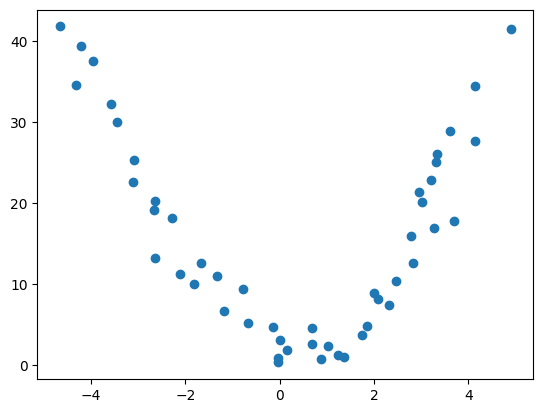

In [4]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

### Relation between x and y follows U pattern which is Non-linear

In [5]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [6]:
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']
model=LinearRegression()

In [7]:
xtrain, xtest, ytrain, ytest= train_test_split(x,y, train_size=0.8, random_state=42)

In [8]:
# plt.scatter(xtrain, ytrain)
# plt.scatter(xtrain, y_pred_train)
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
model.coef_

array([-0.79645711])

In [10]:
model.intercept_

np.float64(16.121749391993667)

### Polynomial Features

In [11]:
from sklearn.preprocessing import PolynomialFeatures

In [12]:
poly=PolynomialFeatures(degree=4)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest= poly.transform(xtest)
print(updated_xtrain)

[[ 1.00000000e+00 -2.11186969e+00  4.45999359e+00 -9.41892528e+00
   1.98915428e+01]
 [ 1.00000000e+00 -3.57855372e+00  1.28060467e+01 -4.58271260e+01
   1.63994832e+02]
 [ 1.00000000e+00  2.31859124e+00  5.37586534e+00  1.24644343e+01
   2.88999281e+01]
 [ 1.00000000e+00 -2.67246083e+00  7.14204687e+00 -1.90868405e+01
   5.10088335e+01]
 [ 1.00000000e+00 -3.94966109e+00  1.55998227e+01 -6.16140128e+01
   2.43354469e+02]
 [ 1.00000000e+00 -3.10844012e+00  9.66239999e+00 -3.00349918e+01
   9.33619735e+01]
 [ 1.00000000e+00  3.21136614e+00  1.03128725e+01  3.31184096e+01
   1.06355339e+02]
 [ 1.00000000e+00  3.27004407e+00  1.06931882e+01  3.49671967e+01
   1.14344274e+02]
 [ 1.00000000e+00  4.13086796e+00  1.70640701e+01  7.04894205e+01
   2.91182489e+02]
 [ 1.00000000e+00 -1.32637898e+00  1.75928121e+00 -2.33347362e+00
   3.09507037e+00]
 [ 1.00000000e+00 -2.65228679e+00  7.03462523e+00 -1.86578436e+01
   4.94859522e+01]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00 -1.61447359e+00

In [13]:
model=LinearRegression()
model.fit(updated_xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00,  1.98915428e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01,  2.88999281e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01,  5.10088335e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01,  1.06355339e+02],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01,  1.14344274e+02],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01,  2.91182489e+02],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00

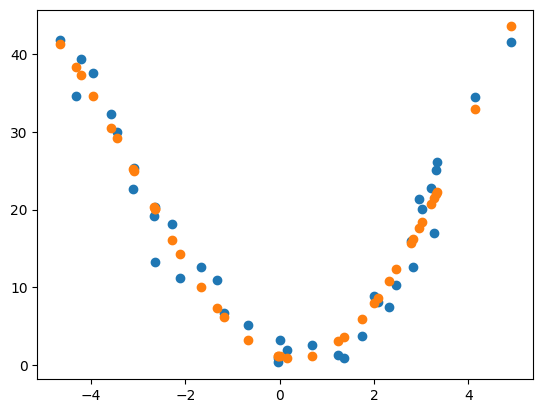

In [15]:
y_pred_train = model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],y_pred_train)

In [16]:
# Train Data
from sklearn.metrics import r2_score
train_score=r2_score(ytrain, y_pred_train)
print(f"train_score: {train_score}")

train_score: 0.9590068634754769


In [17]:
y_pred_test=model.predict(updated_xtest)
test_score=r2_score(ytest, y_pred_test)
print(f'test_score: {test_score}')

test_score: 0.8054468908427623


## When degree=2
## train_score: 0.9413665676490518
## test_score: 0.843055137193884


## When degree=3
## train_score: 0.9469116778215552
## test_score: 0.8405107685716915


## When degree=4
## train_score: 0.9590068634754769
## test_score: 0.8054468908427623

### From above analysis we conclude that, the model is overfit